# Семинар 1 - Основы работы с OpenCV, цветовые пространства, интегральные изображения

***

Источник используемого аэрофотоснимка: https://sovzond.ru/upload/medialibrary/267/%D0%98%D1%81%D1%85%D0%BE%D0%B4%D0%BD%D1%8B%D0%B9-%D0%B0%D1%8D%D1%80%D0%BE%D1%84%D0%BE%D1%82%D0%BE%D1%81%D0%BD%D0%B8%D0%BC%D0%BE%D0%BA.jpg

In [1]:
from pathlib import Path

import cv2
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
IMG_PATH = "/CCM_courses/CV/cv_course_2026/seminars/seminar_01/data/Lenna_test_image.jpeg"

# 1. Основы работы с OpenCV

## Чтение, отображение и сохранение изображений

Для чтения изображения из файла используется функция `cv2.imread`, для отображения изображения на экране - функция `cv2.imshow`, для сохранения изображения в файл - функция `cv2.imwrite`.

`cv2.imread(path, flag)` - читает изображение из файла по пути path. Флаг flag определяет формат считывания изображения. Возможные значения флага:
- `cv2.IMREAD_COLOR` - считывание изображения в цвете (значение по умолчанию, можно не указывать в явном виде)
- `cv2.IMREAD_UNCHANGED` - считывание изображения в цвете "как есть" (с альфа-каналом, если он есть)
- `cv2.IMREAD_GRAYSCALE` - считывание изображения в оттенках серого

In [3]:
img = cv2.imread(IMG_PATH, cv2.IMREAD_COLOR)  # cv2.IMREAD_COLOR обычно не указывают, так как это значение по умолчанию

`cv2.imshow("window_name", image)` - отображает изображение img в окне с именем window_name. Если окно с таким именем не существует, то оно будет создано. Если окно существует, то оно будет очищено и в нем будет отображено изображение img.

Пример кода:
```python
import cv2

img = cv2.imread("image.jpg", cv2.IMREAD_COLOR)
cv2.imshow("image", img)
cv2.waitKey(0)  # ожидание нажатия клавиши, иначе окно закроется сразу же
cv2.destroyAllWindows()  # закрытие всех окон
```

Однако это работает только в скриптах при наличии GUI. Пример такого скрипта: [show_image.py](show_image.py)

В Jupyter Notebook для отображения изображения используется функция `plt.imshow`.

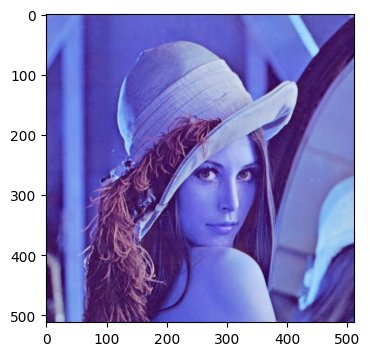

In [4]:
plt.figure(figsize=[4, 4])
plt.imshow(img);

Как видно, цвета изображения неправильные. **Функция `cv2.imread` считывает изображения в формате BGR** (blue, green, red). Чтобы перейти к более привычному представлению RGB (reg, green, blue), который ожидает matplotlib, можно воспользоваться встроенной функцией cvtColor:

In [5]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

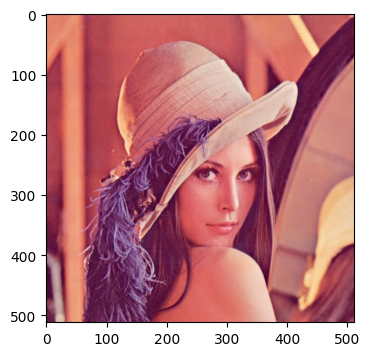

In [6]:
plt.figure(figsize=[4, 4])
plt.imshow(img_rgb);

## Работа с изображением

Загруженное цветное изображение является обычным numpy массивом с тремя размерностями (`shape` - (H, W, C), **channel-last**), каждый элемент которого - целое беззнаковое 8-ми битное число, представляющее квантованную на 256 уровней интенсивность одного из цветов:

In [7]:
print('type(img_rgb) = ', type(img_rgb))
print('img_rgb.shape = ', img_rgb.shape)
print('img_rgb.dtype = ', img_rgb.dtype)

type(img_rgb) =  <class 'numpy.ndarray'>
img_rgb.shape =  (512, 512, 3)
img_rgb.dtype =  uint8


Над изображением можно выполнять те же операции, что и над обычным массивом. Например, рассчитать статистики:

In [8]:
print('img_rgb.min() = ', img_rgb.min())
print('img_rgb.max() = ', img_rgb.max())
print('img_rgb.mean() = ', img_rgb.mean())
print('img_rgb.std() = ', img_rgb.std())
print('np.median(img_rgb) = ', np.median(img_rgb))

img_rgb.min() =  0
img_rgb.max() =  255
img_rgb.mean() =  128.22198232014975


img_rgb.std() =  58.942859735329606
np.median(img_rgb) =  119.0


присвоить какое-либо значение блоку(пикселю):

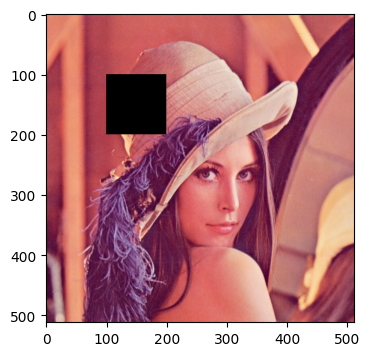

In [9]:
img_rgb_2 = img_rgb.copy()
img_rgb_2[100:200, 100:200] = 0

plt.figure(figsize=[4, 4])
plt.imshow(img_rgb_2);

прибавить какое-либо значение блоку(пикселю):

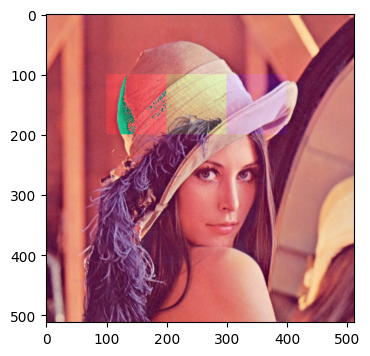

In [10]:
img_rgb_3 = img_rgb.copy()
img_rgb_3[100:200, 100:200, 0] += 40
img_rgb_3[100:200, 200:300, 1] += 40
img_rgb_3[100:200, 300:400, 2] += 40

plt.figure(figsize=[4, 4])
plt.imshow(img_rgb_3);

### Вопрос

- Что произошло с цветами на изображении img_rgb_3? Почему так произошло?

**Ответ:**

На полосе по строкам 100–200 появились три вертикальные зоны с усиленным каналом:
- 100–200 по столбцам — усилен красный (канал 0, +40),
- 200–300 по столбцам — усилен зелёный (канал 1, +40),
- 300–400 по столбцам — усилен синий (канал 2, +40).

В RGB изображении каналы — это индексы 0 (R), 1 (G), 2 (B). К выбранным областям к соответствующему каналу прибавляется 40, поэтому в каждой зоне один цвет становится ярче, и на изображении видны три цветные полосы (красноватая, зеленоватая, синеватая).

## Альтернативы OpenCV

1. Библиотека `Pillow` (Python Imaging Library, PIL). В OpenCV изображения представляются в виде матриц, а в Pillow - в виде объектов класса `Image`.

In [11]:
from PIL import Image

img_pil = Image.open(IMG_PATH)
print('type(img_pil) = ', type(img_pil))
print('img_pil.size = ', img_pil.size)
print('img_pil.mode = ', img_pil.mode)

type(img_pil) =  <class 'PIL.JpegImagePlugin.JpegImageFile'>
img_pil.size =  (512, 512)
img_pil.mode =  RGB


2. Библиотека `scikit-image`. Изображения представлены в виде `np.ndarray`. Порядок каналов - **сразу RGB**. `shape` - (H, W, C), **channel-last**.

type(img_ski) =  <class 'numpy.ndarray'>
img_ski.shape =  (512, 512, 3)
img_ski.dtype =  uint8


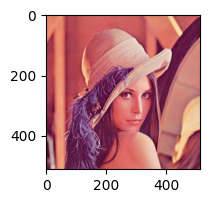

In [12]:
import skimage as ski

img_ski = ski.io.imread(IMG_PATH)
print('type(img_ski) = ', type(img_ski))
print('img_ski.shape = ', img_ski.shape)
print('img_ski.dtype = ', img_ski.dtype)

plt.figure(figsize=[2, 2])
plt.imshow(img_ski);

3. `torchvision` - библиотека для работы с изображениями, входящая в состав PyTorch. Изображения представлены в виде `torch.Tensor`. Порядок каналов - **сразу RGB**. `shape` - (C, H, W), **channel-first**.

In [13]:
from torchvision.io import read_image  # читает изображение сразу в формате torch.Tensor

img_torch = read_image(IMG_PATH)
print('type(img_torch) = ', type(img_torch))
print('img_torch.shape = ', img_torch.shape)
print('img_torch.dtype = ', img_torch.dtype)

type(img_torch) =  <class 'torch.Tensor'>
img_torch.shape =  torch.Size([3, 512, 512])
img_torch.dtype =  torch.uint8


4. **DALI** - библиотека для быстрой обработки изображений на GPU. Подробнее: https://developer.nvidia.com/blog/rapid-data-pre-processing-with-nvidia-dali/

## Упражнения

### Упражнение 1: BGR -> RGB
Реализуйте функцию преобразования изображения в формате BGR в формат RGB

In [14]:
def convert_color_bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return img_bgr[:, :, ::-1].copy()

In [15]:
assert((img_rgb == convert_color_bgr_to_rgb(img)).all())

### Упражнение 2: Изменение яркости
Одним из простейших преобразований изображения является изменение уровня яркости, задаваемое следующим образом:

$$
f'(x, y) = \alpha f(x, y) + \beta
$$

Реализуйте данную операцию с помощью `cv2.convertScaleAbs` - [туториал](https://docs.opencv.org/4.x/d3/dc1/tutorial_basic_linear_transform.html).

В данном упражнении необходимо исследовать работу функции при различных значениях параметров. Протестируйте разные значения alpha и beta, например $\alpha \in \set{0.8, 1, 1.2, 2}$, $\beta \in \set{-10, 0, 10}$

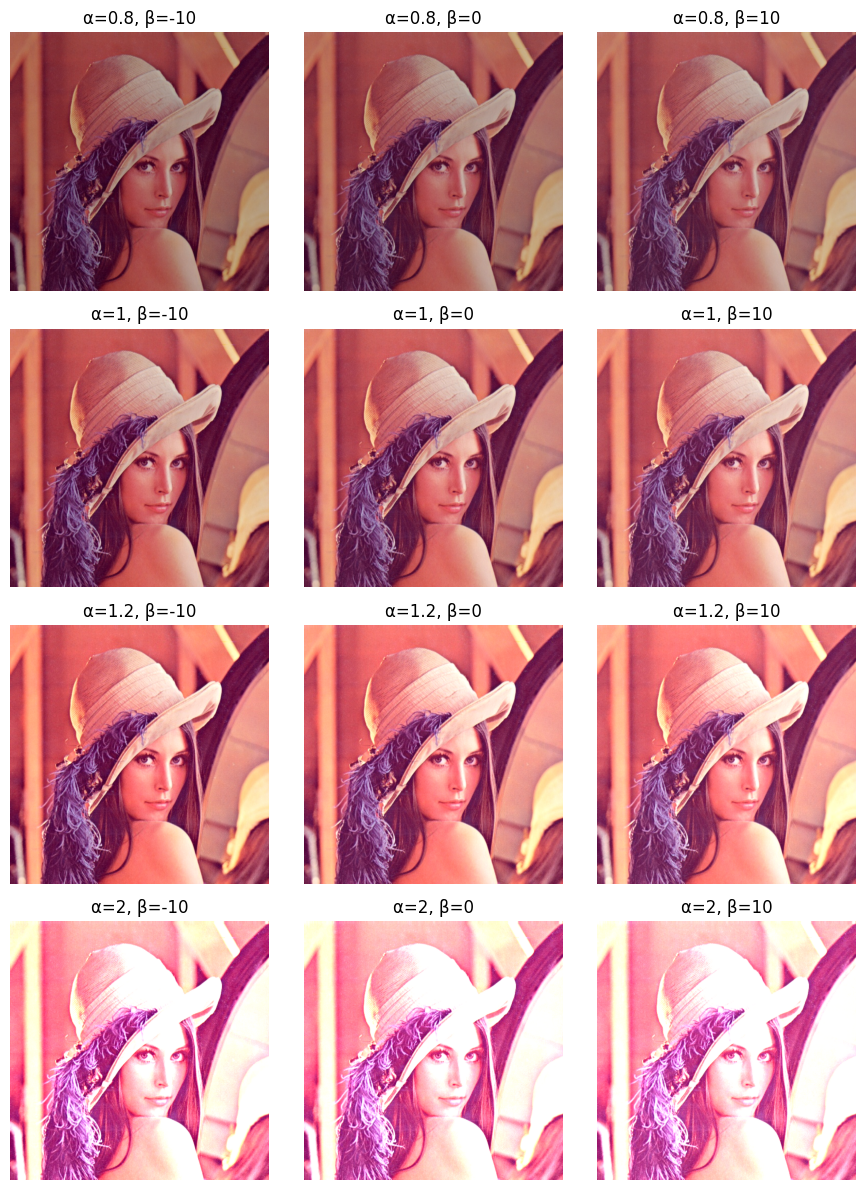

In [16]:
alphas = [0.8, 1, 1.2, 2]
betas = [-10, 0, 10]

fig, axes = plt.subplots(len(alphas), len(betas), figsize=(9, 12))

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        img_new = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)
        axes[i, j].imshow(img_new)
        axes[i, j].set_title(f'α={alpha}, β={beta}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

### Упражнение 3: Смешивание изображений $\alpha - blend$

Другим простым преобразованием является смешивание двух изображений, задаваемое как:

$$
    f'(x, y) = \alpha f_1(x, y) + (1 - \alpha) f_2(x, y)
$$

Реализуйте данную операцию с помощью `cv2.addWeighted` - [туториал](https://docs.opencv.org/3.4/d5/dc4/tutorial_adding_images.html).

Вы можете использовать изображение `data/opencv_logo.jpeg` или загрузить свое.


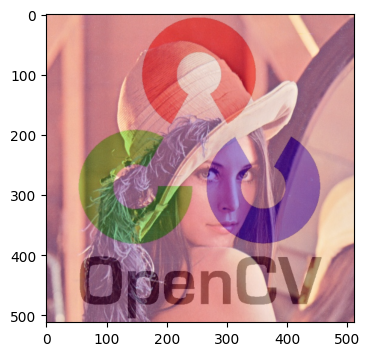

In [17]:
alpha = 0.7
beta = 1 - alpha

logo = cv2.imread('/CCM_courses/CV/cv_course_2026/seminars/seminar_01/data/opencv_logo.jpeg')[..., ::-1]
logo_resized = cv2.resize(logo, (img_rgb.shape[1], img_rgb.shape[0]))

img_new = cv2.addWeighted(img_rgb, alpha, logo_resized, beta, 0)

plt.figure(figsize=[4, 4])
plt.imshow(img_new);

## Нанесение текста и фигур

С помощью OpenCV можно добавить дополнительные элементы на изображение, такие как текст, простые геометрические фигуры и т.д. (см. https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html)

In [18]:
TEXT = 'Lenna 0.99'
UL_CORNER = (200, 200)  # верхний левый угол
FONT = 0                # шрифт
SCALE = 1               # размер
COLOR = (0, 255, 0)     # цвет - зеленый
THICKNESS = 2           # толщина линий

img_rgb_4 = img_rgb.copy()

cv2.putText(img_rgb_4, TEXT, UL_CORNER, FONT, SCALE, COLOR, THICKNESS)
cv2.rectangle(img_rgb_4, UL_CORNER, (370, 400), COLOR, THICKNESS);

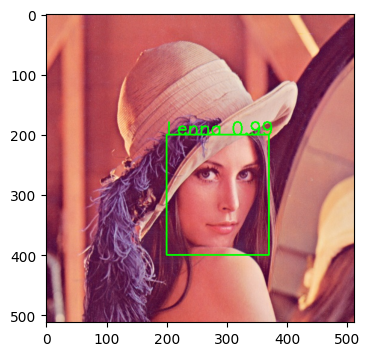

In [19]:
plt.figure(figsize=[4, 4])
plt.imshow(img_rgb_4);

### Вопрос

- Зачем может понадобиться рисовать на изображении?

**Ответ:**

Рисование на изображении нужно для визуальной аннотации: нанесение геометрических примитивов и текста поверх пиксельных данных. Это позволяет явно отмечать области интереса, результаты алгоритмов (детекции, контуры, ключевые точки) и метаданные (подписи, координаты). Такая визуализация используется для проверки корректности кода, интерпретации выводов и представления результатов.

# 2. Фильтр Байера

Сырые изображения, приходящие с камеры, являются байеризованными. Они представлены в виде двумерного массива, где отдельные пиксели кодируют интенсивность синего, зеленого, красного цветов. 

![Фильтр Байера](data/bayer.jpeg)


## Домашнее задание (опциональное)

В ноутбуке [`demosaicing.ipynb`](demosaicing.ipynb).

Вспомогательные материалы - [слайды](slides_demosaicing.pdf).


# Часть 2

In [20]:
AERIAL_IMG_PATH = "/CCM_courses/CV/cv_course_2026/seminars/seminar_01/data/aerial_image.jpg"
SUNFLOWER_IMG_PATH = "/CCM_courses/CV/cv_course_2026/seminars/seminar_01/data/sunflower.jpg"

# 1. Цветовые пространства

Наиболее распространенным представлением цвета пикселя является пространство RGB. В таком представлении цвет представлен тремя числами: интенсивностями красного, зеленого и синего базисных цветов.

In [21]:
img = cv2.imread(SUNFLOWER_IMG_PATH)

In [22]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

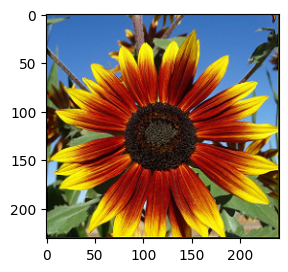

In [23]:
plt.figure(figsize=[3, 3])
plt.imshow(img_rgb);

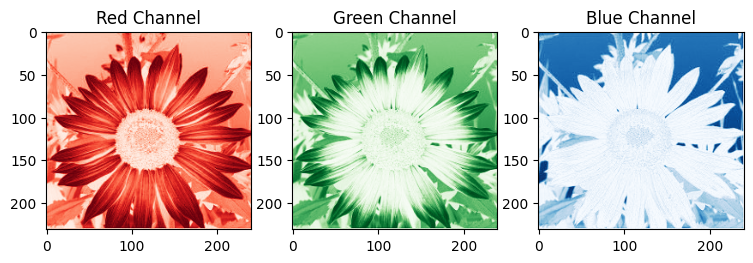

In [24]:
plt.figure(figsize=[9, 3])

plt.subplot(131)
plt.imshow(img_rgb[:,:,0], cmap='Reds')
plt.title('Red Channel')

plt.subplot(132)
plt.imshow(img_rgb[:,:,1], cmap='Greens')
plt.title('Green Channel')

plt.subplot(133)
plt.imshow(img_rgb[:,:,2], cmap='Blues')
plt.title('Blue Channel')

plt.show()

cvtColor поддерживает конвертацию между множеством других цветовых схем. К примеру, чтобы получить серое изобаржение из цветного достаточно:

In [25]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

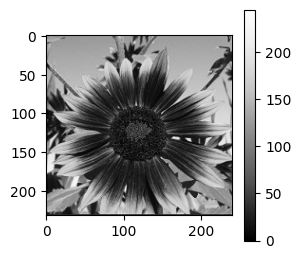

In [26]:
plt.figure(figsize=[3, 3])
plt.imshow(img_gray, cmap='Greys_r')
plt.colorbar()
plt.show()

## Вопрос 1

**Этот и все последующие вопросы - оцениваемые, для самостоятельной работы.**

Можно ли получить черно-белое изображение из RGB представления путем вычисления среднего значения интенсивностей каналов R, G и B? Почему?

**Ответ:** Да, получить серое изображение так можно: каждый пиксель будет равен `(R+G+B)/3`. Но это не совпадает со стандартным преобразованием в градации серого. В OpenCV и в системах цветопередачи используют взвешенную сумму яркости: `0.299·R + 0.587·G + 0.114·B`, потому что чувствительность глаза к каналам разная (сильнее к зелёному, слабее к синему). При простом среднем яркость и контраст будут восприниматься иначе, чем при стандартной формуле.

## Вопрос 2

Почему мы использовали флаг `cmap='Greys_r'` при отображении черно-белого изображения? Чем отличается от `cmap='Greys'`?

**Ответ:** Оба — палитры от чёрного к белому. В `Greys` меньшие значения дают более тёмный цвет (чёрный), большие — более светлый (белый). В `Greys_r` палитра развёрнута: меньшие значения отображаются светлее, большие — темнее. То есть `Greys_r` инвертирует отображение яркости по сравнению с `Greys`. Для обычного серого изображения (0 — тёмное, 255 — светлое) логичнее использовать `Greys`; `Greys_r` используют, когда нужно инвертированное отображение.

Если не предполагается использовать информацию о цвете пикселей, то можно сразу загрузить изображение в оттенках серого:

In [27]:
img_gray = cv2.imread(SUNFLOWER_IMG_PATH, cv2.IMREAD_GRAYSCALE)

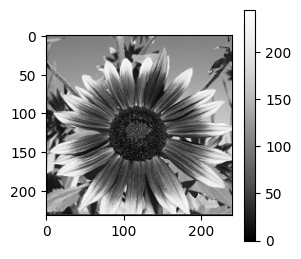

In [28]:
plt.figure(figsize=[3, 3])
plt.imshow(img_gray, cmap='Greys_r')
plt.colorbar()
plt.show()

серое изображение - двумерный массив:

In [29]:
print('type(img_gray) = ', type(img_gray))
print('img_gray.shape = ', img_gray.shape)
print('img_gray.dtype = ', img_gray.dtype)

type(img_gray) =  <class 'numpy.ndarray'>
img_gray.shape =  (231, 240)
img_gray.dtype =  uint8


## Упражнение 1: RGB to gray

**Это и все последующие упражения - оцениваемые, для самостоятельной работы.**

Реализуйте функцию преобразования цветного изображения в формате RGB в серое

In [30]:
def convert_rgb_to_grayscale(img_rgb):
    return np.round(
        0.299 * img_rgb[:, :, 0].astype(np.float64) +
        0.587 * img_rgb[:, :, 1].astype(np.float64) +
        0.114 * img_rgb[:, :, 2].astype(np.float64)
    ).astype(np.uint8)

In [32]:
gray_cv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
gray_ours = convert_rgb_to_grayscale(img_rgb)
assert np.abs(gray_cv.astype(np.int16) - gray_ours.astype(np.int16)).max() <= 1

Кроме RGB/BGR и grayscale существуют и другие цветовые представления. Преобразования между ними можно осуществлять с помощью библиотеки OpenCV следующим способом:

## RGB to HSV

HSV - цветовое пространство, в котором цвет представлен тремя компонентами: Hue (оттенок), Saturation (насыщенность) и Value (значение). Это позволяет задавать цвета в более естественной форме, чем RGB.

**Составляющая H** соответствует цветовому тону и варьируется в пределах 0–360°, в частности 0° – чистый красный цвет, 60° – жёлтый, 120° – зеленый, 180° – голубой, 240° – синий, 300° – фиолетовый.

**Насыщенность S** позволяет оценить насколько «чистым» является данный цвет, она определяет соотношение серого цвета и выбранного оттенка и варьируется от 0 (серый) до 1 (полностью насыщенный).

**Мера яркости V** задает относительную освещенность и измеряется в диапазоне от 0 (черный) до 1 (белый).

Цветовая модель HSV связана с моделью RGB нелинейным преобразованием:
$$
H = 
\begin{cases} 
H_1, & \text{если } B \leq G, \\
360^\circ - H_1, & \text{если } B > G, 
\end{cases}
\text{где } H_1 = \arccos\left( \frac{0.5[(R - G) + (R - B)]}{\sqrt{(R - G)^2 + (R - B)(G - B)}} \right),
$$

$$
S = \frac{\max(R, G, B) - \min(R, G, B)}{\max(R, G, B)}, \quad 
V = \frac{\max(R, G, B)}{255}
$$

In [33]:
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

можно попробовать отобразить изображение так же, как и RGB:

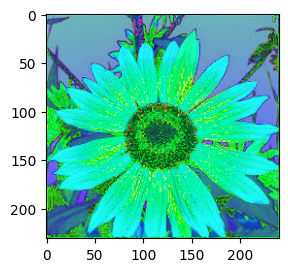

In [34]:
plt.figure(figsize=[3, 3])
plt.imshow(img_hsv);

Однако это не совсем корректно, так как Hue - это угол, а не интенсивность. Поэтому лучше отобразить оттенок в виде цвета, а насыщенность и значение - в виде яркости:

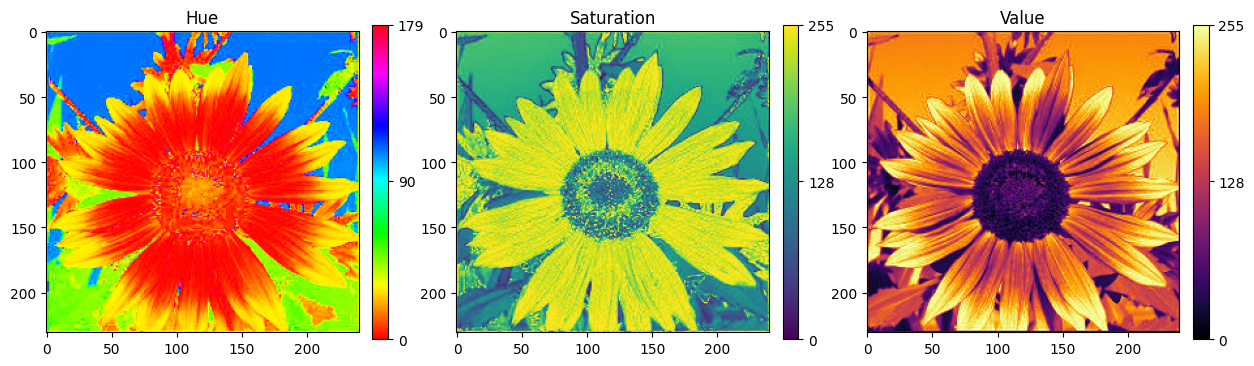

In [35]:
h, s, v = cv2.split(img_hsv)

fig, axs = plt.subplots(1, 3, figsize=[15, 5])

im1 = axs[0].imshow(h, cmap="hsv")
axs[0].set_title('Hue')
cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, ticks=[0, 90, 179])
cbar1.ax.set_yticklabels(['0', '90', '179'])

im2 = axs[1].imshow(s, cmap="viridis")  # Using 'viridis' for Saturation
axs[1].set_title('Saturation')
cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04, ticks=[0, 128, 255])
cbar2.ax.set_yticklabels(['0', '128', '255'])

im3 = axs[2].imshow(v, cmap="inferno")  # Using 'inferno' for Value
axs[2].set_title('Value')
cbar3 = plt.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04, ticks=[0, 128, 255])
cbar3.ax.set_yticklabels(['0', '128', '255'])

plt.show()

## Упражнение 2

Попробуйте другие цветовые пространства, конвертация в которые реализована в OpenCV.

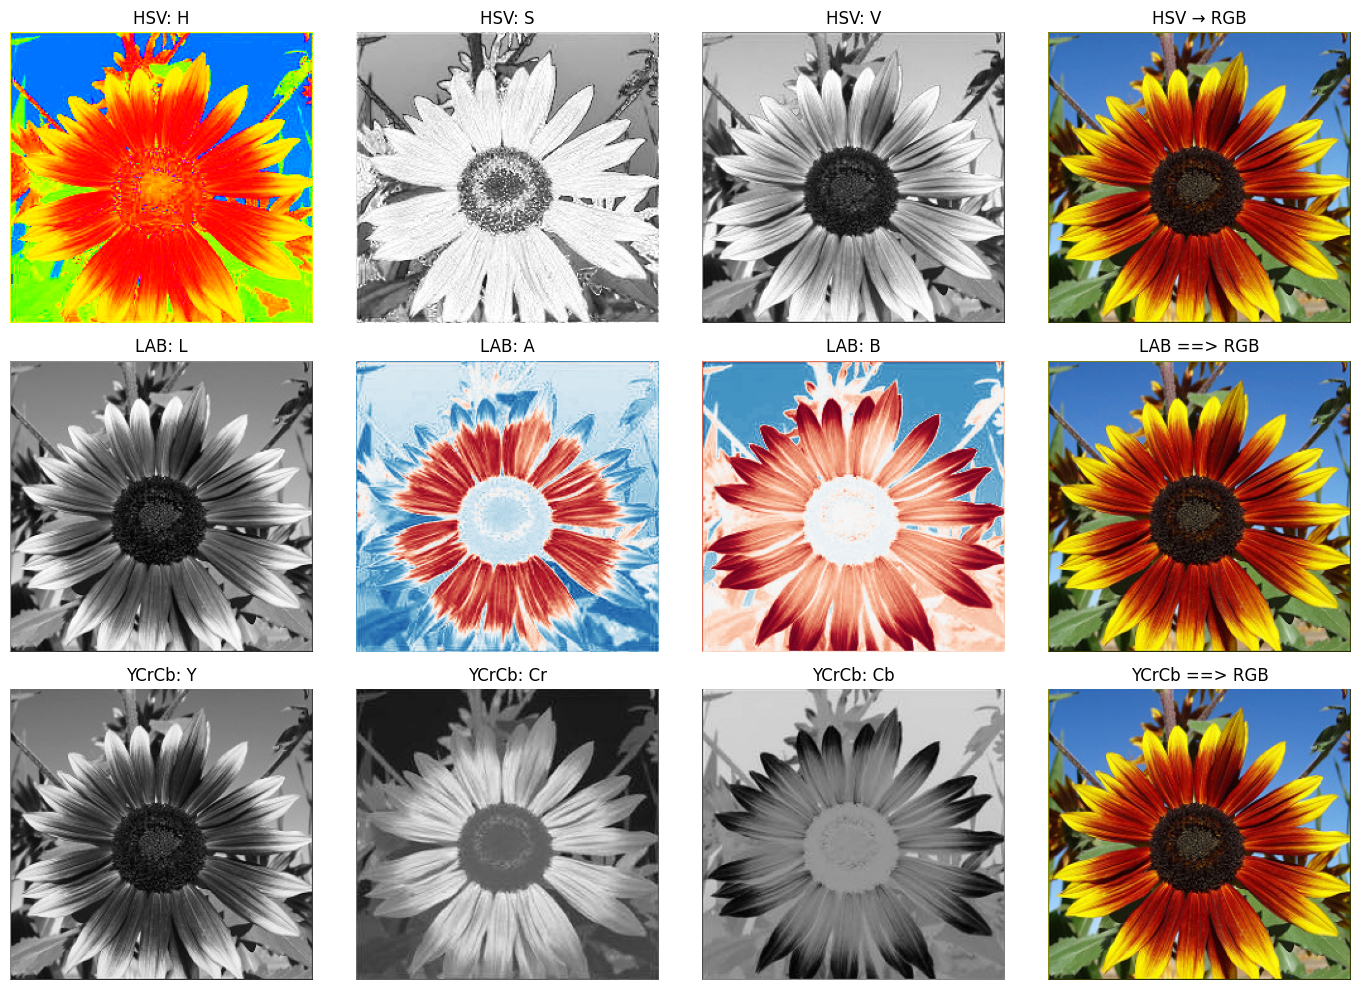

In [38]:
img_bgr = img_rgb[:, :, ::-1].copy()

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

axes[0, 0].imshow(img_hsv[:, :, 0], cmap='hsv')
axes[0, 0].set_title('HSV: H')
axes[0, 1].imshow(img_hsv[:, :, 1], cmap='gray')
axes[0, 1].set_title('HSV: S')
axes[0, 2].imshow(img_hsv[:, :, 2], cmap='gray')
axes[0, 2].set_title('HSV: V')
axes[0, 3].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)[:, :, ::-1])
axes[0, 3].set_title('HSV → RGB')

axes[1, 0].imshow(img_lab[:, :, 0], cmap='gray')
axes[1, 0].set_title('LAB: L')
axes[1, 1].imshow(img_lab[:, :, 1], cmap='RdBu_r')
axes[1, 1].set_title('LAB: A')
axes[1, 2].imshow(img_lab[:, :, 2], cmap='RdBu_r')
axes[1, 2].set_title('LAB: B')
axes[1, 3].imshow(cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)[:, :, ::-1])
axes[1, 3].set_title('LAB ==> RGB')

axes[2, 0].imshow(img_ycrcb[:, :, 0], cmap='gray')
axes[2, 0].set_title('YCrCb: Y')
axes[2, 1].imshow(img_ycrcb[:, :, 1], cmap='gray')
axes[2, 1].set_title('YCrCb: Cr')
axes[2, 2].imshow(img_ycrcb[:, :, 2], cmap='gray')
axes[2, 2].set_title('YCrCb: Cb')
axes[2, 3].imshow(cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2BGR)[:, :, ::-1])
axes[2, 3].set_title('YCrCb ==> RGB')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

## Вопрос 3

В каких задачах переход из RGB в другое цветовое пространство может быть полезным?

**Ответ:**

- Сегментация по цвету — в HSV проще задавать диапазоны по оттенку (H), насыщенности (S) и яркости (V), чем в RGB. Удобно для выделения кожи, дорожной разметки, объектов заданного цвета.

- Сравнение цветов и поиск по цвету — LAB ближе к восприятию человека: L — яркость, a и b — цвет. Евклидово расстояние в LAB лучше отражает «похожесть» цветов, чем в RGB.

- Обработка видео и сжатие — YCrCb разделяет яркость (Y) и цветность (Cr, Cb). Можно сильнее сжимать Cr/Cb при сохранении качества яркости (как в JPEG), или делать фильтры только по яркости.

- Устойчивость к освещению — в HSV и LAB яркость и цвет в той или иной степени разделены, поэтому проще ослабить влияние изменения освещения, работая в основном с каналами цвета (H, a, b) или нормализуя L/V.

- Предобработка для нейросетей — иногда входом делают не RGB, а LAB или YCrCb, чтобы модель явно использовала яркость и цветность по отдельности.

# 2. Гистограмма изображения

Напомним, что гистограммой изображения называется функция, показыващая количество пикселей изображения с заданным в качестве аргумента значением интенсивности:

$$
    h(v) = \sum_{x = 0}^{W - 1} \sum_{y = 0}^{H - 1} [f(x, y) = v] 
$$

Если дополнительно потребовать, чтобы $\sum_{v = 0}^{255} h(v) = 1$, то $h$ будет представлять функцию плотности распределения интенсивности на изображении.

Определим вспомогательную функцию, позволяющую визуализировать гистограмму:

In [39]:
def visualize_hist(hist):
    plt.figure(figsize=[12, 3])
    plt.bar(np.arange(len(hist)), hist / hist.sum())

Рассчитать гистограмму можно с помощью встроенной функции OpenCV:

In [40]:
hist_cv = cv2.calcHist([img_gray],      # список изображений
                       [0],             # список каналов
                       None,            # маска (без маски)
                       [256],           # размер гистограммы
                       [0, 256])[:, 0]  # диапазон значений

Результат представляет собой обычный массив длины 256:

In [41]:
print('hist_cv.shape = ', hist_cv.shape)

hist_cv.shape =  (256,)


и выглядит следующим образом:

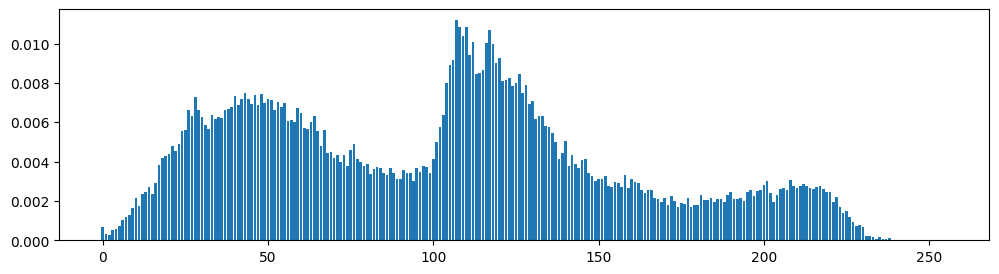

In [42]:
visualize_hist(hist_cv)

## Упражнение 3: Построение гистограммы

Реализуйте функцию для расчета гистограммы изображения. Используйте ее для визуализации трех каналов RGB изображения.

In [43]:
def compute_hist(img):
    hist = np.zeros(256, dtype=np.float64)
    for i in range(256):
        hist[i] = np.sum(img == i)
    return hist

In [44]:
hist_gray = compute_hist(img_gray)

hist_r = compute_hist(img_rgb[:, :, 0])
hist_g = compute_hist(img_rgb[:, :, 1])
hist_b = compute_hist(img_rgb[:, :, 2])

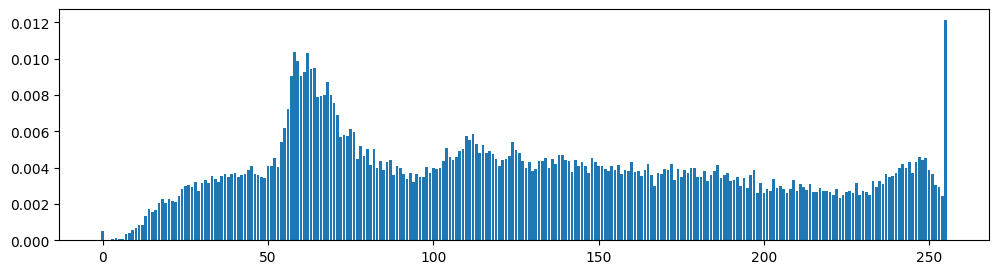

In [45]:
visualize_hist(hist_r)

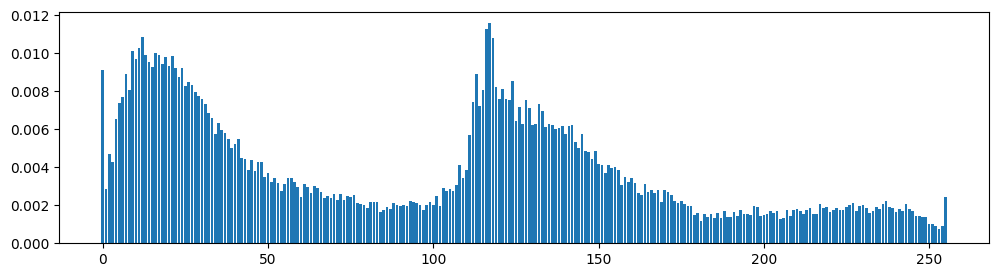

In [46]:
visualize_hist(hist_g)

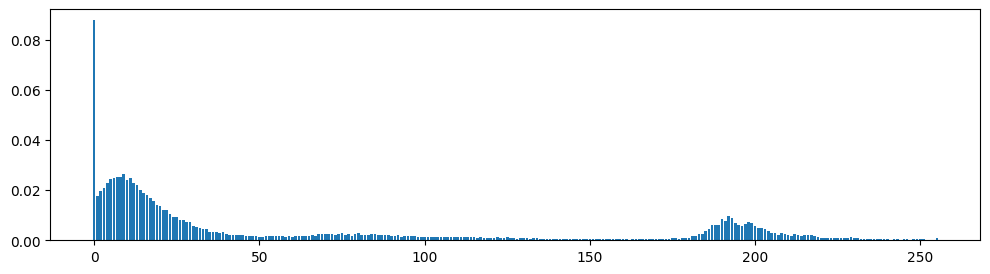

In [47]:
visualize_hist(hist_b)

In [48]:
assert((hist_gray == hist_cv).all())

## Вопрос 4

 Что можно сказать об изображении по его гистограмме?

**Ответ:** По гистограмме можно судить о яркости и контрасте: смещение влево — тёмное изображение, вправо — светлое; узкий разброс — низкий контраст, широкий — высокий. По форме видно, есть ли переэкспозиция или недодержка (скопление у 0 или у 255), преобладание средних тонов или двух яркостных режимов (два пика). Для цветного изображения гистограммы по каналам (R, G, B) показывают доминирующие цвета и цветовой баланс.

## Вопрос 5

Допустим, вы смотрите некоторый фильм и для текущего кадра выводите его гистограмму. Как будет меняться эта гистограмма с течением времени? Опишите несколько случаев: смена камеры, смена освещения, смена сцены.

**Ответ:**

- Смена сцены — гистограмма заметно меняется: другие объекты и цвета дают другое распределение яркостей и каналов (новые пики, другая форма).

- Смена освещения — в целом та же сцена, но гистограмма сдвигается: при затемнении — сдвиг влево (больше низких яркостей), при осветлении — вправо; контраст может измениться (сужается или расширяется разброс).

- Смена камеры — возможны сдвиг яркости и другая форма гистограммы из‑за иной гаммы, баланса белого и чувствительности, даже при той же сцене и освещении.

## Упражнение 4: JPEG и гистограмма

Исследуйте, как влияет степень сжатия алгоритма JPEG на вид гистограммы изображения.

Используйте черно-белое изображение `img_gray`. Визуализируйте степени сжатия 90, 60, 30, 5.

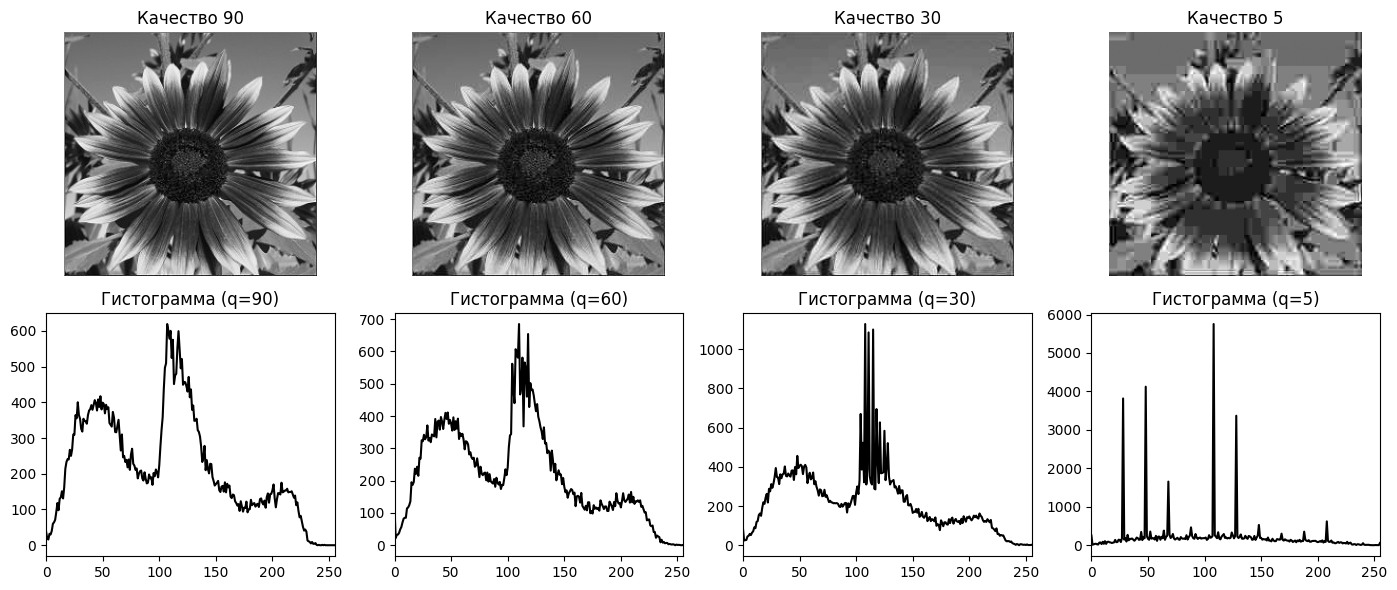

In [49]:
qualities = [90, 60, 30, 5]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i, q in enumerate(qualities):
    _, buf = cv2.imencode('.jpg', img_gray, [cv2.IMWRITE_JPEG_QUALITY, q])
    img_jpeg = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    
    axes[0, i].imshow(img_jpeg, cmap='gray')
    axes[0, i].set_title(f'Качество {q}')
    axes[0, i].axis('off')
    
    hist = cv2.calcHist([img_jpeg], [0], None, [256], [0, 256])
    axes[1, i].plot(hist, color='black')
    axes[1, i].set_title(f'Гистограмма (q={q})')
    axes[1, i].set_xlim(0, 255)

plt.tight_layout()
plt.show()

## Упражнение 5: Сегментация

На загруженном аэроортофотоплане выделите зеленые насаждения. Для этого постройте бинарную маску, где 1 будет отвечать наличию насаждений в данном пикселе, 0 - их отсутствию, и визуализируйте её. А также рассчитайте, какую долю изображения занимают зеленые насаждения. С какой ошибкой (погрешностью) получена эта величина?

**Подсказка:** вам должно помочь HSV пространство и гистограмма. Погрешность может быть оценена на глаз, по вашей неуверенности в определении порога отделения классов 'зеленые насаждения'/'прочее'.

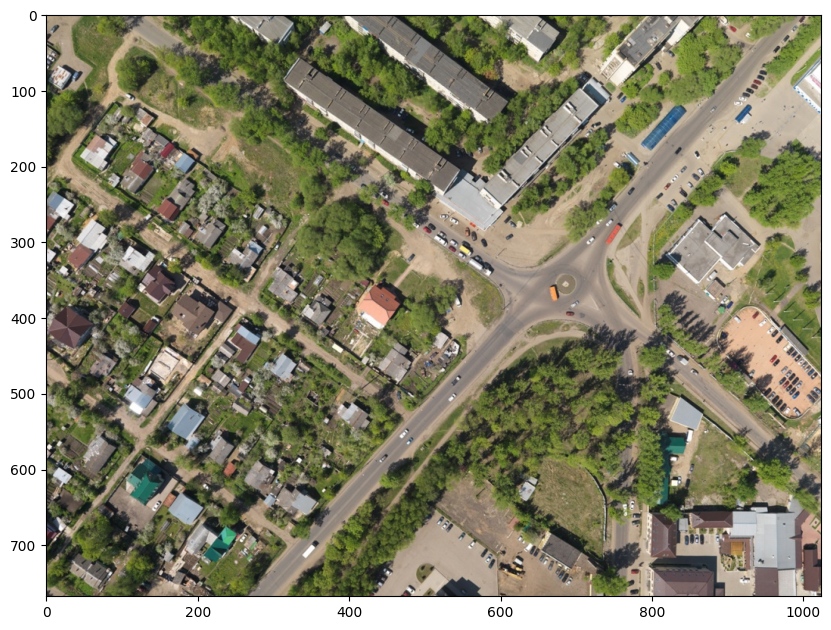

In [50]:
aerial_image = cv2.cvtColor(cv2.imread(AERIAL_IMG_PATH), cv2.COLOR_BGR2RGB)

plt.figure(figsize=[10, 10])
plt.imshow(aerial_image);

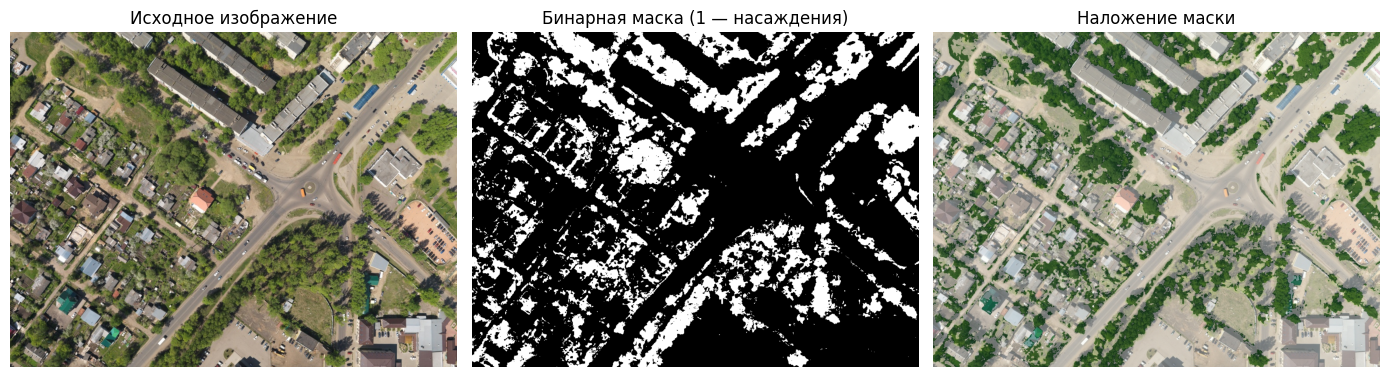

Доля зелёных насаждений: 25.38% (199572 / 786432 пикселей)


In [51]:
img_hsv = cv2.cvtColor(aerial_image, cv2.COLOR_RGB2HSV)
h, s, v = img_hsv[:, :, 0], img_hsv[:, :, 1], img_hsv[:, :, 2]

H_MIN, H_MAX = 35, 85
S_MIN = 40
V_MIN = 40

mask = ((h >= H_MIN) & (h <= H_MAX) & (s >= S_MIN) & (v >= V_MIN)).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(aerial_image)
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Бинарная маска (1 — насаждения)')
axes[1].axis('off')

axes[2].imshow(aerial_image)
axes[2].imshow(mask, cmap='Greens', alpha=0.4)
axes[2].set_title('Наложение маски')
axes[2].axis('off')
plt.tight_layout()
plt.show()

total_pixels = mask.size
vegetation_pixels = mask.sum()
fraction = vegetation_pixels / total_pixels
print(f'Доля зелёных насаждений: {fraction:.2%} ({vegetation_pixels} / {total_pixels} пикселей)')

In [52]:
fractions = []
for h_min in [30, 35, 40]:
    for h_max in [80, 85, 90]:
        m = ((h >= h_min) & (h <= h_max) & (s >= S_MIN) & (v >= V_MIN)).astype(np.uint8)
        fractions.append(m.sum() / m.size)
delta = max(fractions) - min(fractions)
print(f'При варьировании порогов H доля меняется в диапазоне {min(fractions):.2%}–{max(fractions):.2%}.')
print(f'Погрешность оценки доли (из-за выбора порога): порядка {delta/2:.1%}–{delta:.1%}.')

При варьировании порогов H доля меняется в диапазоне 6.85%–34.31%.
Погрешность оценки доли (из-за выбора порога): порядка 13.7%–27.5%.


Величина доли зависит от выбранных порогов по H, S и V. При сдвиге границ «зелёного» диапазона (например, H_min в 30–40, H_max в 80–90) доля меняется на несколько процентов. Погрешность можно оценить как порядка 5–10% от полученной доли (или ± несколько процентных пунктов), в зависимости от того, насколько однозначно на снимке разделяются зелень, почва, тени и прочие объекты.

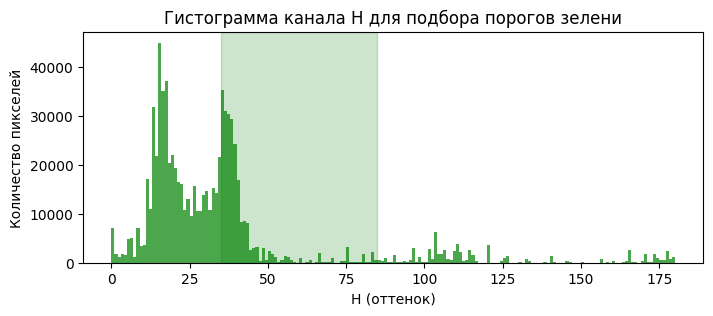

In [53]:
plt.figure(figsize=(8, 3))
plt.hist(h.ravel(), bins=180, range=(0, 180), color='green', alpha=0.7)
plt.xlabel('H (оттенок)')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма канала H для подбора порогов зелени')
plt.axvspan(H_MIN, H_MAX, alpha=0.2, color='green')
plt.show()

# 3. Интегральные изображения

## Упражнение 6

Напомним, что интегральным изображением называется следующая функция:

$$
    I(x, y) = \sum_{i = 0}^{x} \sum_{j = 0}^{y} f(i, j)
$$

С помощью интегрального изображения можно за $O(1)$ вычислять сумму интенсивностей в произвольной прямоугольной области. Требуется реализовать расчет интегрального изображения, а также быстрый расчет сумм интенсивностей в прямоугольнике заданном верхним левым углом, шириной и высотой $x, y, w, h$.

$$
    L(x,y) = I(x,y) + L(x,y-1) + L(x-1,y) – L(x-1,y-1)
$$

<img src="data/input_image.jpg" width="30%" /> <img src="data/integral_image.jpg" width="30%" /> <img src="data/rect.jpg" width="30%" />

In [54]:
class IntegralImage:

    def __init__(self, img):
        assert len(img.shape) == 2  # только для серых изображений
        self.img = img
        H, W = img.shape
        self.L = np.zeros((H + 1, W + 1), dtype=np.float64)
        for i in range(1, H + 1):
            for j in range(1, W + 1):
                self.L[i, j] = (
                    img[i - 1, j - 1]
                    + self.L[i - 1, j]
                    + self.L[i, j - 1]
                    - self.L[i - 1, j - 1]
                )

    def sum(self, x, y, w, h):
        return (
            self.L[y + h, x + w]
            - self.L[y, x + w]
            - self.L[y + h, x]
            + self.L[y, x]
        )

In [55]:
I = IntegralImage(img_gray)

In [56]:
x, y, w, h = 0, 0, 100, 100
assert(img_gray[y:y + h, x:x + w].sum() == I.sum(x, y, w, h))

x, y, w, h = 100, 100, 100, 100
assert(img_gray[y:y + h, x:x + w].sum() == I.sum(x, y, w, h))

## Вопрос 6

В каких задачах может потребоваться использовать интегральное изображение?

**Ответ:**

- Детекторы объектов — много прямоугольных признаков по всему изображению и по масштабам; суммы по окнам считаются за O(1) вместо O(площади).

- Быстрое вычисление скользящего среднего (blur) — сумма в окне за O(1), что даёт быструю аппроксимацию размытия по прямоугольнику.

- Адаптивная пороговая обработка — порог как среднее по локальному прямоугольнику (сумма/площадь через интегральное изображение).

- Расчёт корреляции и шаблонов — предподсчёт сумм по областям ускоряет вычисление SSD, cross-correlation по множеству сдвигов и размеров окна.

- Оценка яркости/контраста по региону — сумма и сумма квадратов (два интегральных изображения) дают среднее и дисперсию по любому прямоугольнику за O(1).